In [24]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, ConfusionMatrixDisplay
)

from src.data_loader import load_data
from src.preprocess import split_xy, build_preprocessor

# Classification Models

We use the **collapsed category groupings** from the statistical analysis
(education, marital status, region) along with binned age and hours-per-week.
The raw columns they replace are dropped before modeling.

1. **Logistic Regression** -- interpretable baseline, gives coefficient estimates
2. **Random Forest** -- ensemble of decision trees, typically higher accuracy

In [25]:
df = load_data(use_cleaned=True)
print("Shape:", df.shape)

split = split_xy(df)
print(f"Train size: {len(split.X_train)}  Test size: {len(split.X_test)}")
print(f"\nTarget distribution (train):\n{split.y_train.value_counts(normalize=True)}")
print(f"\nFeatures used ({len(split.X_train.columns)}):")
print(list(split.X_train.columns))

Shape: (48794, 15)
Train size: 39035  Test size: 9759

Target distribution (train):
income
<=50K    0.760599
>50K     0.239401
Name: proportion, dtype: float64

Features used (14):
['age', 'workclass', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'education_grouped', 'marital_grouped', 'age_group', 'hours_group', 'region']


## Logistic Regression Baseline

In [ ]:
preprocessor_lr = build_preprocessor(split.X_train)

logreg_pipe = Pipeline([
    ('preprocess', preprocessor_lr),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
])

logreg_pipe.fit(split.X_train, split.y_train)
y_pred_lr = logreg_pipe.predict(split.X_test)

print("=== Logistic Regression ===")
print(classification_report(split.y_test, y_pred_lr))

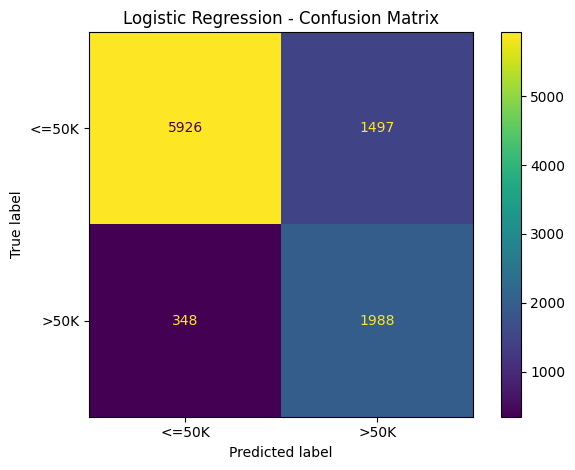

In [ ]:
ConfusionMatrixDisplay.from_predictions(split.y_test, y_pred_lr)
plt.title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Top feature coefficients
feature_names_lr = logreg_pipe.named_steps['preprocess'].get_feature_names_out()
coefs = logreg_pipe.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_names_lr, 'coefficient': coefs})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print("Top 15 features by absolute coefficient:")
print(coef_df.head(15).to_string(index=False))

Top 15 features by absolute coefficient:
                                feature  coefficient  abs_coef
                      num__capital-gain     2.289131  2.289131
       cat__education_grouped_Before HS    -1.878692  1.878692
           cat__marital_grouped_Married     1.410678  1.410678
     cat__marital_grouped_Never Married    -1.114592  1.114592
       cat__education_grouped_Doctorate     1.098902  1.098902
            cat__age_group_Early Career    -1.053413  1.053413
    cat__education_grouped_Professional     1.028587  1.028587
                 cat__relationship_Wife     0.933078  0.933078
     cat__education_grouped_High School    -0.932564  0.932564
        cat__occupation_Farming-fishing    -0.912830  0.912830
cat__marital_grouped_Previously Married    -0.859681  0.859681
          cat__occupation_Other-service    -0.772589  0.772589
                 cat__hours_group_11-25    -0.739613  0.739613
        cat__occupation_Exec-managerial     0.729481  0.729481
       cat__re

### Coefficients Split by Direction

In logistic regression, the sign of the coefficient tells you the **direction** of the effect:
- **Positive coefficient** → the feature increases the probability of earning **>50K**
- **Negative coefficient** → the feature increases the probability of earning **<=50K**

The table above ranks by absolute value (overall importance regardless of direction).
Below we split them so you can see which features favor each income group separately.

In [ ]:
# Features that INCREASE probability of >50K (positive coefficients)
pos_df = coef_df[coef_df['coefficient'] > 0].sort_values('coefficient', ascending=False)
print("Top 15 features favoring >50K:")
print(pos_df.head(15)[['feature', 'coefficient']].to_string(index=False))

print()

# Features that INCREASE probability of <=50K (negative coefficients)
neg_df = coef_df[coef_df['coefficient'] < 0].sort_values('coefficient', ascending=True)
print("Top 15 features favoring <=50K:")
print(neg_df.head(15)[['feature', 'coefficient']].to_string(index=False))

Top 15 features favoring >50K:
                            feature  coefficient
                  num__capital-gain     2.289131
       cat__marital_grouped_Married     1.410678
   cat__education_grouped_Doctorate     1.098902
cat__education_grouped_Professional     1.028587
             cat__relationship_Wife     0.933078
    cat__occupation_Exec-managerial     0.729481
    cat__occupation_Protective-serv     0.613273
                cat__age_group_Peak     0.570178
       cat__occupation_Tech-support     0.552601
             cat__hours_group_41-60     0.543470
     cat__occupation_Prof-specialty     0.520474
     cat__education_grouped_Masters     0.464181
         cat__workclass_Federal-gov     0.458900
                           num__age     0.421352
       cat__race_Asian-Pac-Islander     0.365008

Top 15 features favoring <=50K:
                                feature  coefficient
       cat__education_grouped_Before HS    -1.878692
     cat__marital_grouped_Never Married    -1.

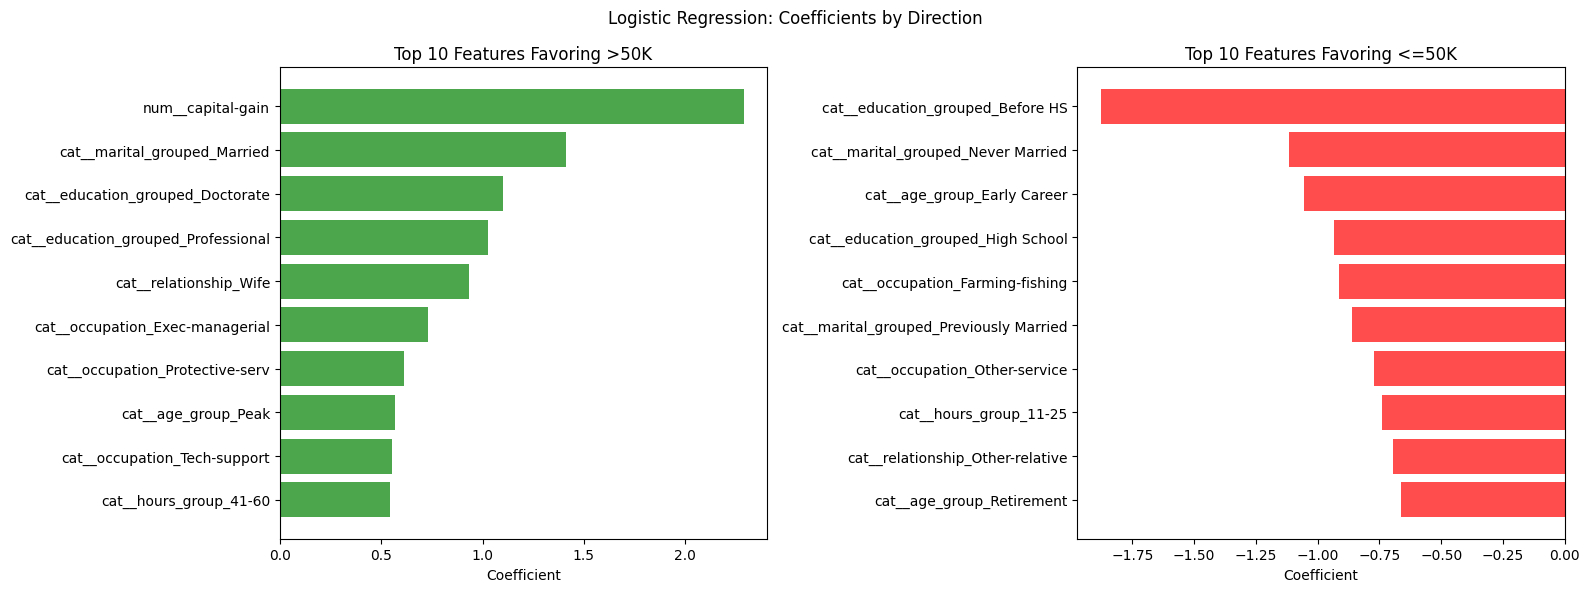

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top_pos = pos_df.head(10)
ax1.barh(top_pos['feature'][::-1], top_pos['coefficient'][::-1], color='green', alpha=0.7)
ax1.set_xlabel('Coefficient')
ax1.set_title('Top 10 Features Favoring >50K')

top_neg = neg_df.head(10)
ax2.barh(top_neg['feature'][::-1], top_neg['coefficient'][::-1], color='red', alpha=0.7)
ax2.set_xlabel('Coefficient')
ax2.set_title('Top 10 Features Favoring <=50K')

plt.suptitle('Logistic Regression: Coefficients by Direction')
plt.tight_layout()
plt.show()

## Random Forest Classifier

In [ ]:
preprocessor_rf = build_preprocessor(split.X_train)

rf_pipe = Pipeline([
    ('preprocess', preprocessor_rf),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(split.X_train, split.y_train)
y_pred_rf = rf_pipe.predict(split.X_test)

print("=== Random Forest ===")
print(classification_report(split.y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

       <=50K       0.94      0.81      0.87      7423
        >50K       0.59      0.85      0.69      2336

    accuracy                           0.82      9759
   macro avg       0.77      0.83      0.78      9759
weighted avg       0.86      0.82      0.83      9759



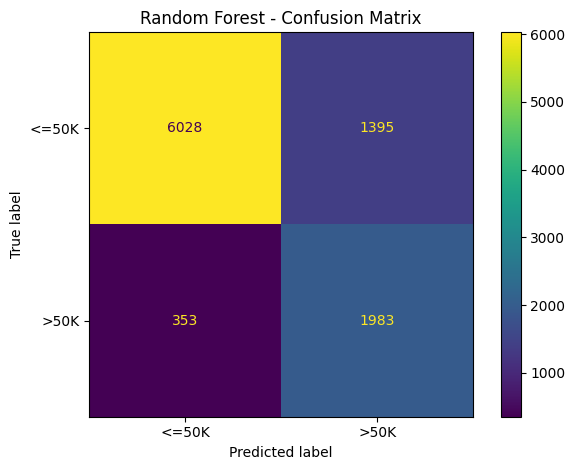

In [ ]:
ConfusionMatrixDisplay.from_predictions(split.y_test, y_pred_rf)
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

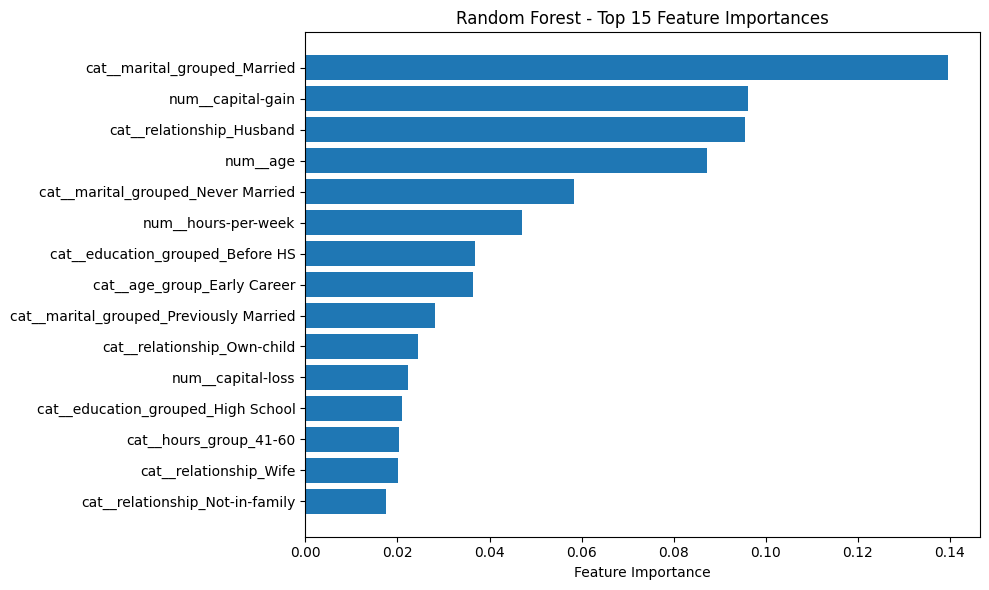

In [ ]:
# Feature importances
feature_names_rf = rf_pipe.named_steps['preprocess'].get_feature_names_out()
importances = rf_pipe.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'feature': feature_names_rf, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df['feature'].head(15)[::-1], imp_df['importance'].head(15)[::-1])
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest - Top 15 Feature Importances')
plt.tight_layout()
plt.show()

## Model Comparison

In [ ]:
def score_model(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (weighted)': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall (weighted)': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1 (weighted)': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

comparison = pd.DataFrame([
    score_model('Logistic Regression', split.y_test, y_pred_lr),
    score_model('Random Forest', split.y_test, y_pred_rf),
])

comparison = comparison.set_index('Model').round(4)
comparison

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
Model,,,,
Logistic Regression,0.8109,0.8550,0.8109,0.8217
Random Forest,0.8209,0.8591,0.8209,0.8305


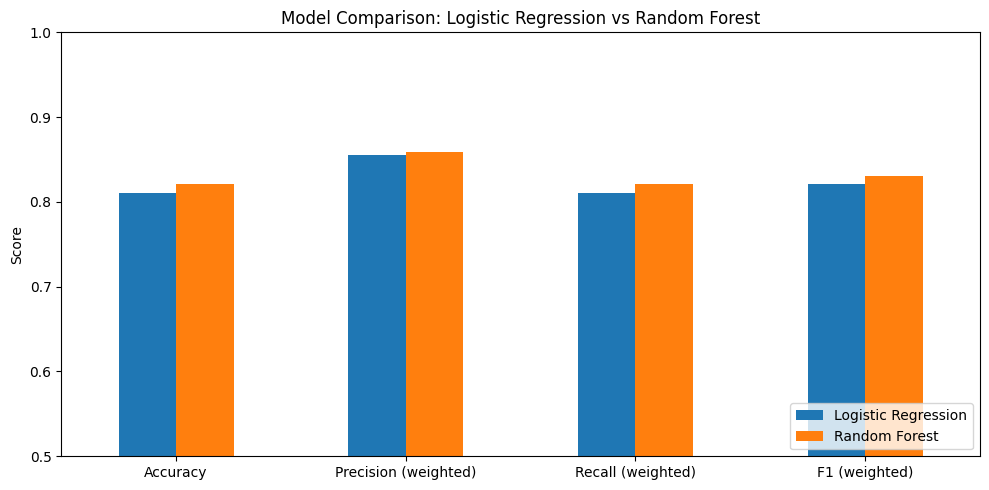

In [ ]:
comparison.T.plot(kind='bar', figsize=(10, 5), rot=0)
plt.ylabel('Score')
plt.title('Model Comparison: Logistic Regression vs Random Forest')
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()